In [ ]:
#===========================================>
#   Healthcare Intelligence Platform     #
#===========================================>


In [ ]:
# DIABETES TRAINING - Train model and save
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/healthcare_data/diabities.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# --- Data cleaning ---
df = df.drop_duplicates()


In [ ]:
# Replace zero values in medical columns with median of non-zero
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    if col in df.columns:
        median_val = df[df[col] > 0][col].median()
        df[col] = df[col].replace(0, median_val)
        print(f"{col}: zeros replaced with {median_val:.1f}")
df = df.fillna(df.median())

Glucose: zeros replaced with 117.0
BloodPressure: zeros replaced with 72.0
SkinThickness: zeros replaced with 29.0
Insulin: zeros replaced with 125.0
BMI: zeros replaced with 32.3


Saved: diabetes_viz.png


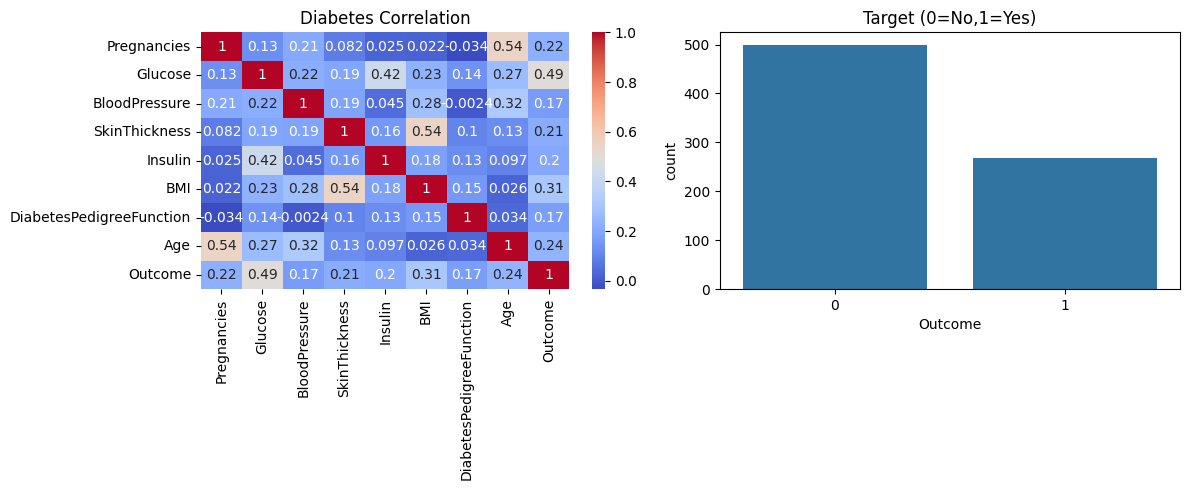

In [ ]:
 #--- Visualisation (saves images) ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Diabetes Correlation")
plt.subplot(1,2,2)
sns.countplot(x='Outcome', data=df)
plt.title("Target (0=No,1=Yes)")
plt.tight_layout()
plt.savefig("diabetes_viz.png")
print("Saved: diabetes_viz.png")

In [ ]:
# --- Train-test split ---
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# --- Model training ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# --- Evaluation ---
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7403
Confusion Matrix:
 [[78 21]
 [19 36]]


In [ ]:
# --- Save model ---
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/diabetes_model.pkl")
joblib.dump(scaler, "models/diabetes_scaler.pkl")
print("✅ Model saved to models/diabetes_model.pkl")

✅ Model saved to models/diabetes_model.pkl


In [ ]:
#=====> Heart Disease Prediction<====

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/healthcare_data/Heart Disease.csv")
print("Shape:", df.shape)
print(df.head())


Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [ ]:
# --- Data cleaning ---
df = df.replace('?', pd.NA)
df = df.drop_duplicates()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.fillna(df.median())
print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


Saved: heart_viz.png


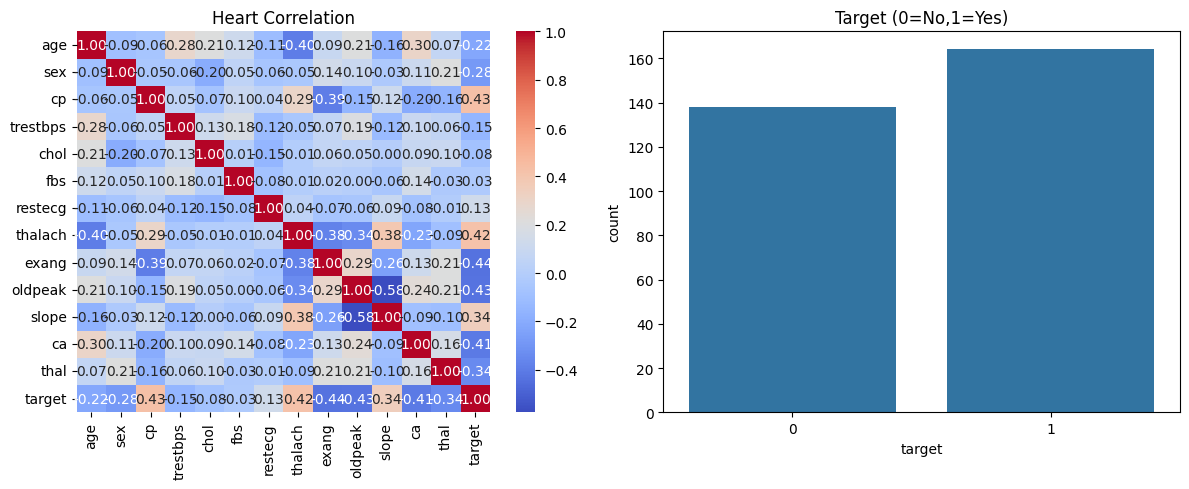

In [ ]:
# --- Visualisation ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heart Correlation")
plt.subplot(1,2,2)
sns.countplot(x='target', data=df)
plt.title("Target (0=No,1=Yes)")
plt.tight_layout()
plt.savefig("heart_viz.png")
print("Saved: heart_viz.png")

In [ ]:

# --- Train-test split ---
X = df.drop("target", axis=1)
y = df["target"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:

# --- Model training ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:

# --- Evaluation ---
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8361
Confusion Matrix:
 [[25  7]
 [ 3 26]]


In [ ]:
# --- Save model ---
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/heart_model.pkl")
joblib.dump(scaler, "models/heart_scaler.pkl")
print("✅ Model saved to models/heart_model.pkl")

✅ Model saved to models/heart_model.pkl


In [ ]:
#=====>Hospital Readmission<=====

In [ ]:
# -------------------- LOAD DATA --------------------
df = pd.read_csv("/content/drive/MyDrive/healthcare_data/readmission.csv")

print("Original shape:", df.shape)
print(df.head())

Original shape: (25000, 17)
       age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0  [70-80)                 8                72             1             18   
1  [70-80)                 3                34             2             13   
2  [50-60)                 5                45             0             18   
3  [70-80)                 2                36             0             12   
4  [60-70)                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty       diag_1  \
0             2            0            0           Missing  Circulatory   
1             0            0            0             Other        Other   
2             0            0            0           Missing  Circulatory   
3             1            0            0           Missing  Circulatory   
4             0            0            0  InternalMedicine        Other   

        diag_2       diag_3 glucose_test

In [ ]:

# -------------------- 2. DATA CLEANING --------------------
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Convert age range to numeric
def age_to_num(x):
    if pd.isna(x):
        return 65
    x = x.strip("[]()")
    parts = x.split("-")
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) // 2
    return 65

df["age_num"] = df["age"].apply(age_to_num)

# Create binary target: 'yes' = 1, 'no' = 0
df["target"] = df["readmitted"].apply(lambda x: 1 if x == "yes" else 0)

print("\nTarget distribution:")
print(df["target"].value_counts())
print(f"Readmission rate: {df['target'].mean():.2%}")

After removing duplicates: (25000, 19)

Target distribution:
target
0    13246
1    11754
Name: count, dtype: int64
Readmission rate: 47.02%


In [ ]:

# -------------------- 3. FEATURE SELECTION --------------------
features = [
    "time_in_hospital",
    "n_lab_procedures",
    "n_procedures",
    "n_medications",
    "n_outpatient",
    "n_inpatient",
    "n_emergency",
    "age_num"
]
X = df[features].copy()
y = df["target"]

# Fill missing values
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

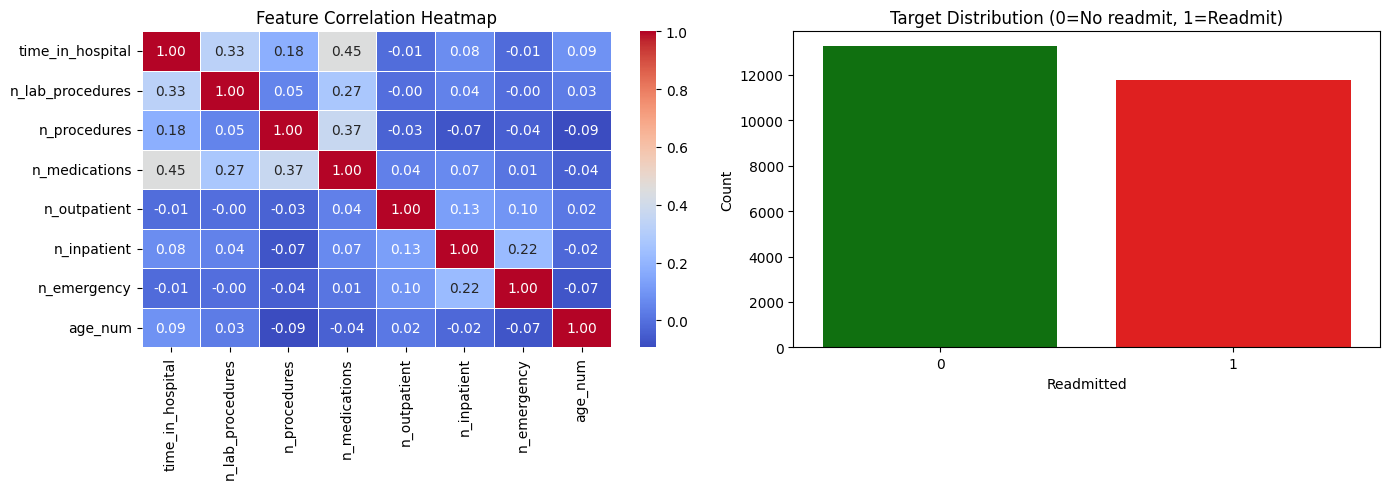

✅ Visualizations saved as 'readmission_viz.png'


In [ ]:
# -------------------- 4. VISUALIZATION (Only 2 Graphs) --------------------
plt.figure(figsize=(14, 5))

# Graph 1: Correlation Heatmap (no change needed)
plt.subplot(1, 2, 1)
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=12)

# Graph 2: Target Distribution (FIXED)
plt.subplot(1, 2, 2)
sns.countplot(x=y, hue=y, palette=['green', 'red'], legend=False)
plt.title("Target Distribution (0=No readmit, 1=Readmit)", fontsize=12)
plt.xlabel("Readmitted")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("readmission_viz.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualizations saved as 'readmission_viz.png'")

In [ ]:

# -------------------- 5. TRAIN-TEST SPLIT --------------------
# Use test_size=0.2, but if positive cases are very few, increase to 0.3
test_size = 0.2
if y.sum() < 50:
    test_size = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train readmission rate: {y_train.mean():.2%}")
print(f"Test readmission rate: {y_test.mean():.2%}")


Training set size: 20000
Test set size: 5000
Train readmission rate: 47.02%
Test readmission rate: 47.02%


In [ ]:

# -------------------- 6. SCALING --------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

# -------------------- 7. MODEL TRAINING --------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:

# -------------------- 8. EVALUATION (Accuracy + Confusion Matrix) --------------------
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n✅ Model Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)

if y_test.nunique() >= 2:
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
else:
    print("⚠️ Test set had only one class (possible if readmission very rare).")


✅ Model Accuracy: 0.6090
Confusion Matrix:
[[1826  823]
 [1132 1219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.69      0.65      2649
           1       0.60      0.52      0.55      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000



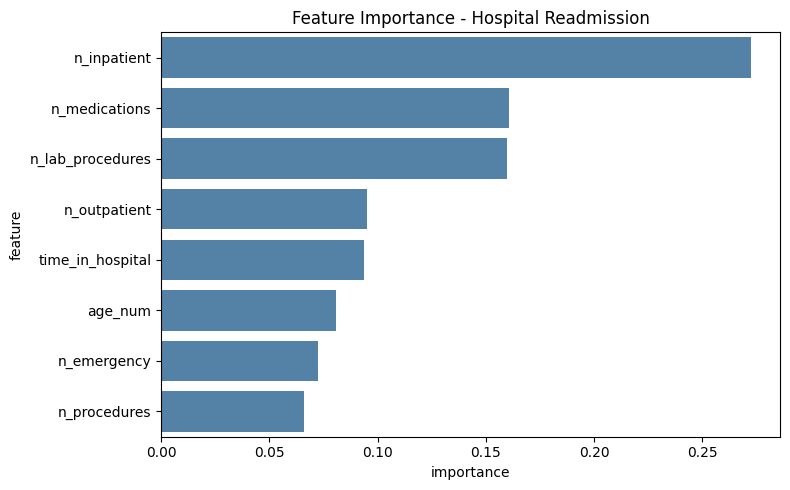

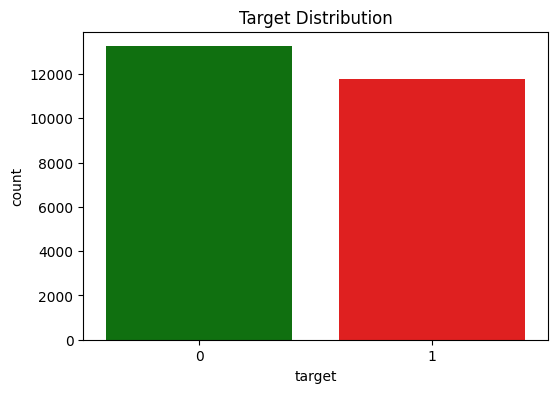

In [ ]:


# -------------------- 9. FEATURE IMPORTANCE --------------------
feature_imp = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
feature_imp = feature_imp.sort_values('importance', ascending=False)

# Feature Importance - Fixed
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp, x='importance', y='feature', color='steelblue')
plt.title("Feature Importance - Hospital Readmission")
plt.tight_layout()
plt.show()

# Target Distribution - Fixed
plt.figure(figsize=(6,4))
sns.countplot(x=y, hue=y, palette=['green', 'red'], legend=False)
plt.title("Target Distribution")
plt.show()

In [ ]:

# -------------------- 10. SAVE MODEL --------------------
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/readmission_model.pkl")
joblib.dump(scaler, "models/readmission_scaler.pkl")
print("\n✅ Model and scaler saved to 'models/' folder")


✅ Model and scaler saved to 'models/' folder


In [ ]:
#=====>Disease Clustering<=====

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib
import os

In [ ]:
# Load data
df = pd.read_csv("/content/drive/MyDrive/healthcare_data/disease clustering.csv")
print("Shape:", df.shape)

Shape: (768, 9)


In [ ]:
# Drop target column if present
if "Outcome" in df.columns:
    df = df.drop("Outcome", axis=1)

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [ ]:

# --- Data cleaning ---
df = df.drop_duplicates()
df = df.fillna(df.median())

In [ ]:

# --- Scale data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Saved: elbow.png


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

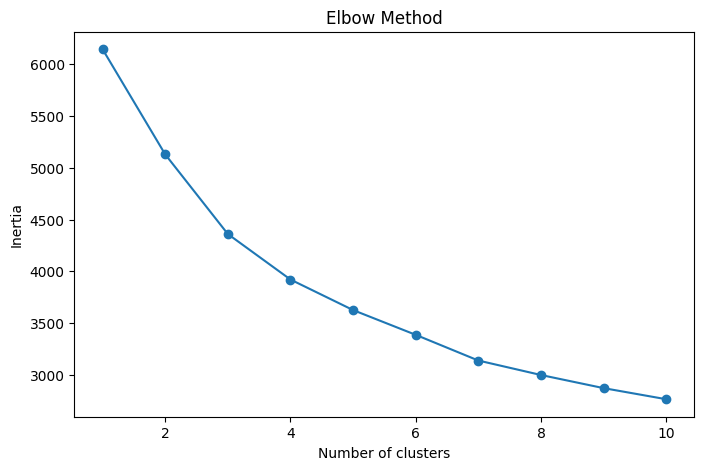

In [ ]:
# --- Elbow method to find optimal k ---
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.savefig("elbow.png")
print("Saved: elbow.png")

In [ ]:
# --- Train KMeans with k=3 ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

Saved: clusters_viz.png


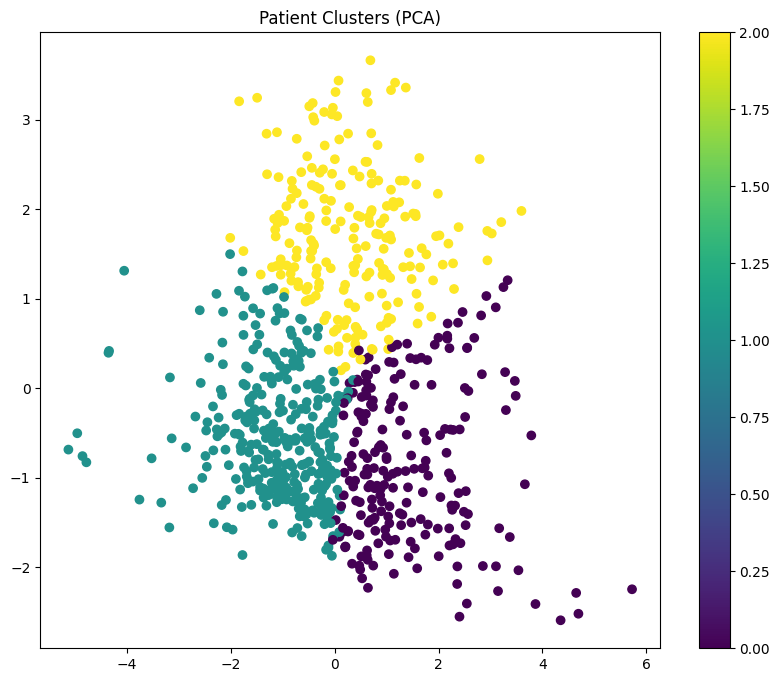

In [ ]:
# --- Visualisation with PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title("Patient Clusters (PCA)")
plt.savefig("clusters_viz.png")
print("Saved: clusters_viz.png")

In [ ]:
# --- Save model ---
os.makedirs("models", exist_ok=True)
joblib.dump(kmeans, "models/clustering_model.pkl")
joblib.dump(scaler, "models/clustering_scaler.pkl")
print("✅ Model saved to models/clustering_model.pkl")

✅ Model saved to models/clustering_model.pkl


In [ ]:
#=====>Medicine Recommendation<====


In [ ]:
# MEDICINE RECOMMENDATION - Rule based (no ML)
# This file only defines the medicine database (no training)
import pandas as pd

In [ ]:
# Medicine dictionary
medicine_db = {
    "Diabetes": [
        "Metformin 500mg – twice daily with meals",
        "Insulin (as prescribed) – monitor blood glucose",
        "Glipizide 5mg – before meals"
    ],
    "Hypertension": [
        "Lisinopril 10mg – once daily",
        "Amlodipine 5mg – once daily",
        "Metoprolol 50mg – twice daily"
    ],
    "Heart Disease": [
        "Aspirin 81mg – once daily",
        "Atorvastatin 20mg – once daily",
        "Metoprolol 25mg – twice daily"
    ],
    "High Cholesterol": [
        "Simvastatin 20mg – once daily at bedtime",
        "Atorvastatin 40mg – once daily",
        "Fenofibrate 145mg – once daily"
    ],
    "Fever": [
        "Acetaminophen 500mg – every 4-6 hours",
        "Ibuprofen 400mg – every 6-8 hours",
        "Rest and increase fluid intake"
    ],
    "Headache": [
        "Acetaminophen 500mg – every 4-6 hours",
        "Ibuprofen 200mg – every 6-8 hours",
        "Apply cold compress"
    ],
    "Cough": [
        "Dextromethorphan 15mg – every 4 hours",
        "Honey and warm water",
        "Stay hydrated"
    ],
    "Cold": [
        "Rest and fluids",
        "Pseudoephedrine 30mg – for congestion",
        "Throat lozenges"
    ]
}
print("Medicine database ready.")

Medicine database ready.
